# 🧪 OpenCV Lab — Session 1: Advanced Image Manipulation & Histograms
**Estimated Duration:** ~2 hours

**Tools Required:** OpenCV, NumPy, Matplotlib

**Dataset:** Use any image you want (`lena.png`, sunset/landscape/football image, etc.)

In [ ]:
from google.colab import files
img1=files.upload()


Saving Lena.png to Lena.png


## 🔹 Part 1 — Essential Manipulations

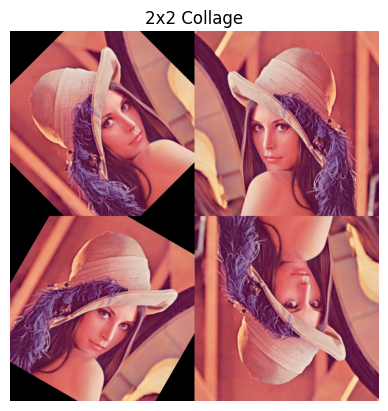

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Lena.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Resize (fixed size)
resized1 = cv2.resize(img, (img.shape[1]//2, img.shape[0]//2))
# Resize (scaling factor)
resized2 = cv2.resize(img, None, fx=0.5, fy=0.5)

# Rotation
(h, w) = img.shape[:2]
center = (w // 2, h // 2)
M1 = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated1 = cv2.warpAffine(img, M1, (w, h))
M2 = cv2.getRotationMatrix2D(center, -30, 1.0)
rotated2 = cv2.warpAffine(img, M2, (w, h))

# Crop center
start_x = w // 2 - 100
start_y = h // 2 - 100
cropped = img[start_y:start_y+200, start_x:start_x+200]

# Flip
flip_h = cv2.flip(img, 1)
flip_v = cv2.flip(img, 0)

# Collage
collage = np.vstack([
    np.hstack([rotated1, flip_h]),
    np.hstack([rotated2, flip_v])
])

plt.imshow(collage)
plt.title('2x2 Collage')
plt.axis('off')
plt.show()

Answer questions:


*   Rotation may cut off corners if the canvas isn't resized. Using fixed size can distort aspect ratio.


*   Scale factor is useful when maintaining proportional resizing.

## 🔹 Part 2 — Image Histogram Analysis

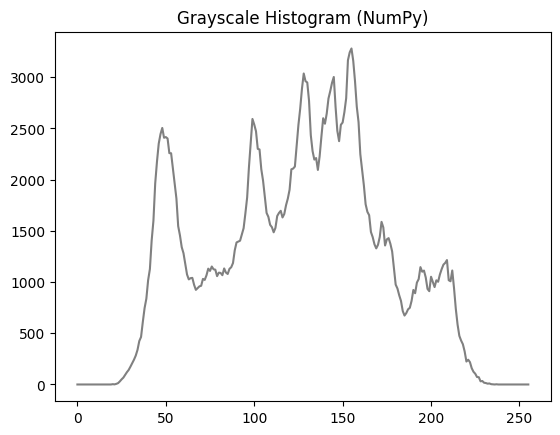

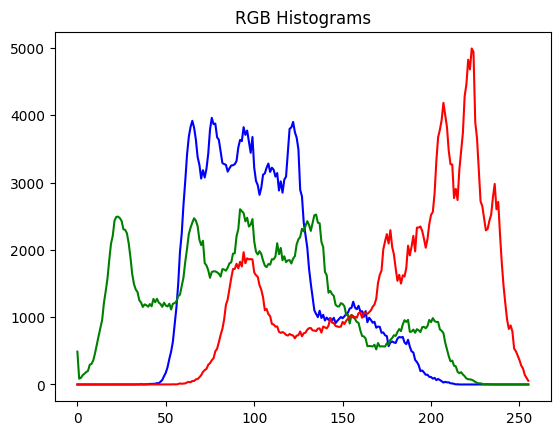

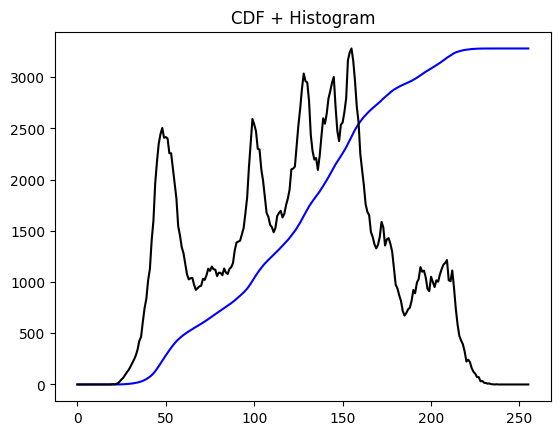

In [ ]:
gray = cv2.cvtColor(cv2.imread('Lena.png'), cv2.COLOR_BGR2GRAY)

# Histogram using cv2.calcHist
#hist = cv2.calcHist([gray], [0], None, [256], [0,256])
#plt.plot(hist, color='black')
#plt.title('Grayscale Histogram (cv2)')
#plt.show()

# Using numpy
hist_np, _ = np.histogram(gray.flatten(), 256, [0,256])
plt.plot(hist_np, color='gray')
plt.title('Grayscale Histogram (NumPy)')
plt.show()

# RGB Histogram
img = cv2.imread('Lena.png')
color = ('b','g','r')
for i, col in enumerate(color):
    histr = cv2.calcHist([img], [i], None, [256], [0,256])
    plt.plot(histr, color=col)
plt.title('RGB Histograms')
plt.show()

# CDF overlay
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max() / cdf.max()
plt.plot(cdf_normalized, color='blue')
plt.plot(hist, color='black')
plt.title('CDF + Histogram')
plt.show()

Answers:



*   An image with a wider histogram has better contrast.
*   Histogram peaks indicate dominant tones (dark, mid, or bright).



## 🔹 Part 3 — Histogram Equalization Techniques

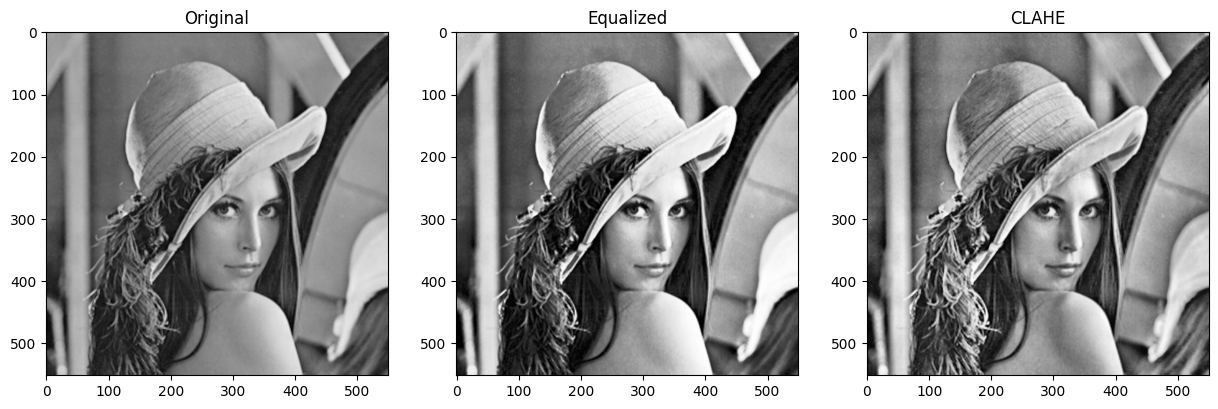

In [ ]:
# Standard Equalization
equalized = cv2.equalizeHist(gray)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(gray)

# LAB CLAHE
img = cv2.imread('Lena.png')
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe_l = clahe.apply(l)
lab_clahe = cv2.merge((clahe_l, a, b))
clahe_bgr = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

# Show
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].imshow(gray, cmap='gray')
axs[0].set_title('Original')
axs[1].imshow(equalized, cmap='gray')
axs[1].set_title('Equalized')
axs[2].imshow(cl1, cmap='gray')
axs[2].set_title('CLAHE')
plt.show()

Answers:

*   CLAHE avoids over-amplifying noise and is more local.

*   Higher clipLimit increases contrast but may cause haloing.

*   Standard equalization may create artificial brightness.




## 🔹 Part 4 — Color Masking and Region Isolation

In [ ]:
from google.colab import files
img1=files.upload()

Saving tomatoes_colors.png to tomatoes_colors.png


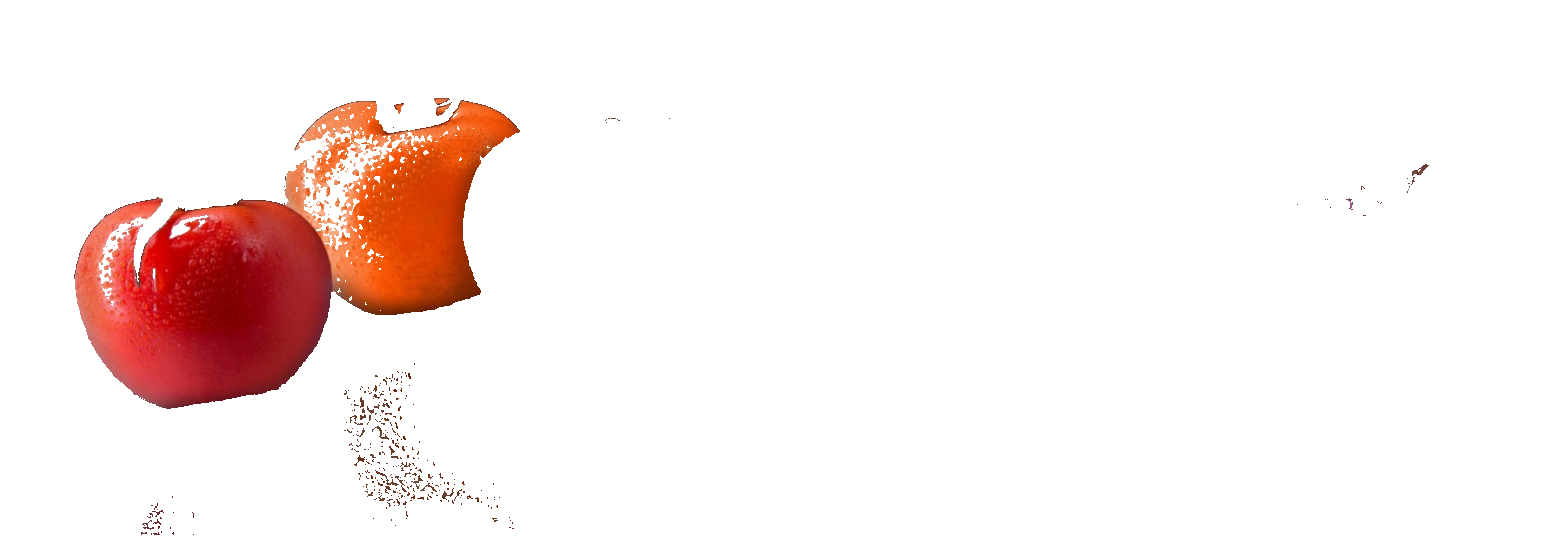

In [ ]:
from google.colab.patches import cv2_imshow

img = cv2.imread('tomatoes_colors.png')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Red mask
lower1 = np.array([0, 100, 100])
upper1 = np.array([10, 255, 255])
lower2 = np.array([160, 100, 100])
upper2 = np.array([179, 255, 255])
mask1 = cv2.inRange(hsv, lower1, upper1)
mask2 = cv2.inRange(hsv, lower2, upper2)
mask = cv2.bitwise_or(mask1, mask2)

# Isolate region
result = cv2.bitwise_and(img, img, mask=mask)

# White background
white_bg = np.full_like(img, 255)
final = cv2.copyTo(img, mask, white_bg)

cv2_imshow(final)
cv2.waitKey(0)
cv2.destroyAllWindows()

Answers:



*   HSV better separates hue from brightness, more reliable for color filtering.
*   bitwise_xor highlights unique areas; bitwise_or merges masks.



## 🔹 Part 5 — Mini Project: Color Poster Effect

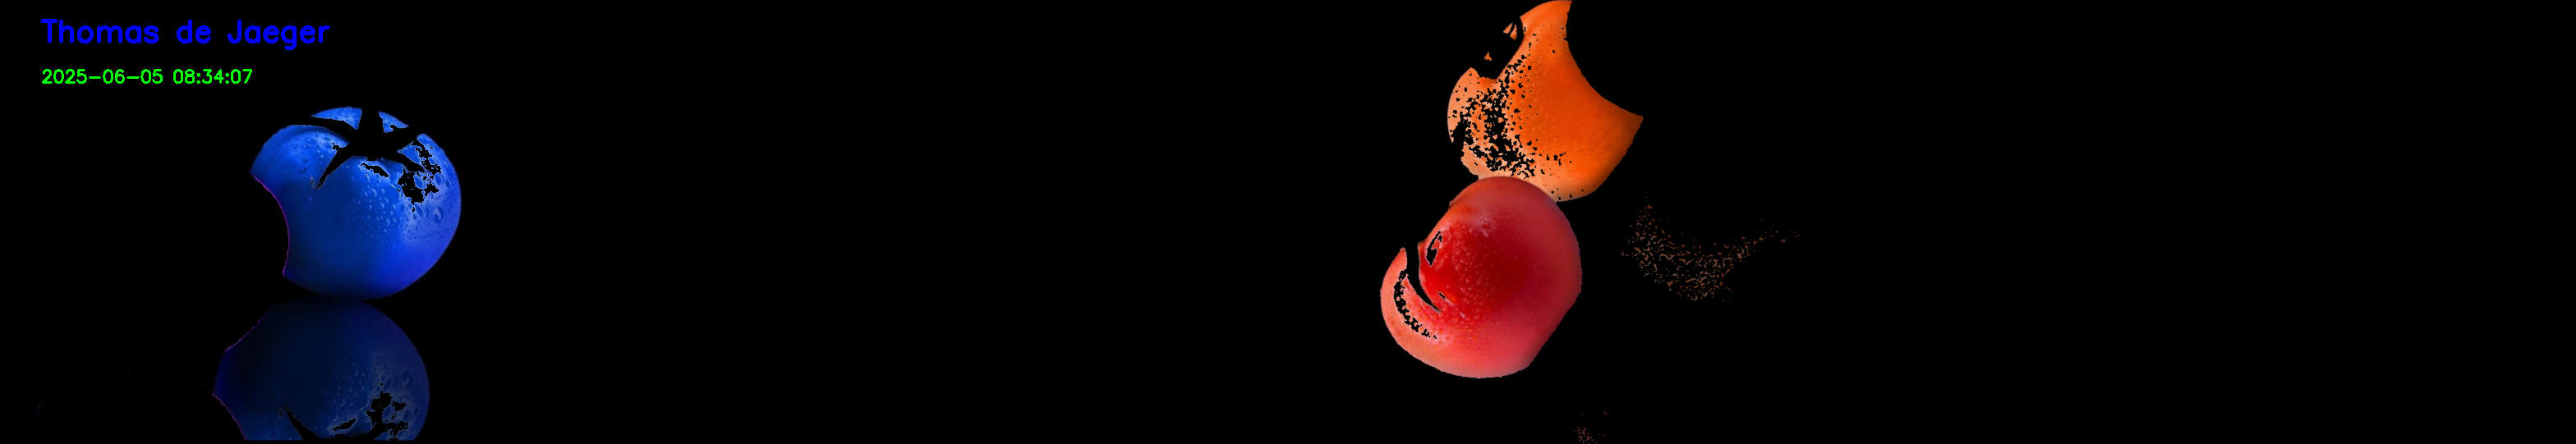

In [ ]:
# Use the masked image from above
# Apply transformations to selected color regions
blue_lower = np.array([100, 150, 0])
blue_upper = np.array([140, 255, 255])
mask_blue = cv2.inRange(hsv, blue_lower, blue_upper)
blue = cv2.bitwise_and(img, img, mask=mask_blue)
flip_blue = cv2.flip(blue, 1)

rotated_red = cv2.warpAffine(result, M1, (img.shape[1], img.shape[0]))
poster = np.hstack((flip_blue, rotated_red))

cv2.putText(poster, 'Thomas de Jaeger', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (256,0,0), 3)
from datetime import datetime
cv2.putText(poster, datetime.now().strftime('%Y-%m-%d %H:%M:%S'), (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,256,0), 2)
cv2_imshow(poster)
cv2.waitKey(0)
cv2.destroyAllWindows()